In [1]:
import sys

from pathlib import Path

import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import torch
import torch.nn.functional as F
from IPython.display import Audio, display
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm

from configuration import (
    SAMPLE_RATE, HOP_LENGTH, BATCH_SIZE, DIFF_EPOCHS, LR, T, LATENT_CHANNELS,
    DATA_GLOB, OUTPUT_DIR, GEN_SAMPLE_PATH,
    VAE_CKPT_PATH, DIFFUSION_CKPT_PATH, LATENT_STATS_PATH, HISTOGRAM_PATH,
    device,
)
from dataset import MelDataset, trim_to_shape
from models import (
    VAE, UNetDenoiser, LatentDataset,
    betas, alphas, alpha_bars,
    q_sample, sample_latents,
    mel_tensor_to_audio,
)

print('device:', device)

/home/matej/Documents/DIPLRAD/music_gen_v2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
from dataset.create_chunks import iter_chunks
# audio_files = sorted(Path().glob(DATA_GLOB))
audio_files = iter_chunks("../musdb18/musdb18_mixtures", "train", 10, 15)
# print('found files:', len(audio_files))
# if len(audio_files) == 0:
#    raise FileNotFoundError(f'No WAV files found matching: {DATA_GLOB}')

In [3]:
# ── Build dataset & loaders ────────────────────────────────────────────────────
dataset = MelDataset(audio_files)
n_val   = max(1, int(0.2 * len(dataset))) if len(dataset) > 1 else 0
n_train = len(dataset) - n_val

if n_val > 0:
    train_ds, val_ds = random_split(dataset, [n_train, n_val])
else:
    train_ds = val_ds = dataset

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_mel = next(iter(train_loader))
mel_shape  = tuple(sample_mel.shape[-2:])
print('mel shape:', mel_shape)

mel shape: (80, 216)


In [4]:
# ── Load trained VAE ───────────────────────────────────────────────────────────
vae = VAE().to(device)
ckpt = torch.load(VAE_CKPT_PATH, map_location=device)
vae.load_state_dict(ckpt['model_state'])
vae.eval()
print(f'Loaded VAE from {VAE_CKPT_PATH}')

Loaded VAE from ../musdb18/output/vae_checkpoint.pt


In [5]:
def encode_dataset_with_mean(model, loader):

    model.eval()
    mu_list = []
    with torch.no_grad():
        for x in tqdm(loader, desc='encoding latents (mu)', leave=False):
            x = x.to(device)
            mu, _ = model.encoder(x)
            mu_list.append(mu.cpu())
    mu_all = torch.cat(mu_list, dim=0)

    latent_mean = mu_all.mean(dim=(0, 2, 3), keepdim=True)   # (1, C, 1, 1)
    latent_std  = mu_all.std( dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
    mu_norm     = (mu_all - latent_mean) / latent_std
    return {
        'mu':           mu_all,
        'mu_norm':      mu_norm,
        'latent_mean':  latent_mean,
        'latent_std':   latent_std,
    }


latent_bundle = encode_dataset_with_mean(vae, train_loader)
latent_train  = latent_bundle['mu_norm']
latent_mean   = latent_bundle['latent_mean']
latent_std    = latent_bundle['latent_std']
latent_shape  = tuple(latent_train.shape[1:])


assert latent_mean.shape == (1, LATENT_CHANNELS, 1, 1)
assert latent_std.shape  == (1, LATENT_CHANNELS, 1, 1)

torch.save({
    'latent_mean':  latent_mean,
    'latent_std':   latent_std,
    'latent_shape': latent_shape,
    'mel_shape':    mel_shape,
}, LATENT_STATS_PATH)

print('latent train shape:', latent_train.shape)
print('latent mean shape:', latent_mean.shape, '| latent std shape:', latent_std.shape)

latent train shape: torch.Size([276, 16, 10, 27])
latent mean shape: torch.Size([1, 16, 1, 1]) | latent std shape: torch.Size([1, 16, 1, 1])


In [6]:

def maybe_load_diffusion(model, path=DIFFUSION_CKPT_PATH, map_location=device):
    path = Path(path)
    if path.exists():
        ckpt = torch.load(path, map_location=map_location)
        model.load_state_dict(ckpt['model_state'])
        print(f'Loaded diffusion checkpoint from {path}')
        return ckpt
    print(f'No diffusion checkpoint at {path}, training from scratch.')
    return None


def save_diffusion_checkpoint(model, latent_mean, latent_std, latent_shape, mel_shape,
                               history=None, path=DIFFUSION_CKPT_PATH):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        'model_state':  model.state_dict(),
        'latent_mean':  latent_mean.detach().cpu(),
        'latent_std':   latent_std.detach().cpu(),
        'latent_shape': latent_shape,
        'mel_shape':    mel_shape,
        'history':      history,
    }, path)
    torch.save({
        'latent_mean':  latent_mean.detach().cpu(),
        'latent_std':   latent_std.detach().cpu(),
        'latent_shape': latent_shape,
        'mel_shape':    mel_shape,
    }, LATENT_STATS_PATH)
    print(f'Saved diffusion checkpoint to {path}')
    print(f'Saved latent stats to {LATENT_STATS_PATH}')

In [7]:

def train_diffusion(model, latent_loader, epochs=DIFF_EPOCHS, lr=LR):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        losses = []
        for z in tqdm(latent_loader, leave=False):
            z = z.to(device)
            t = torch.randint(0, T, (z.size(0),), device=device)
            zt, noise = q_sample(z, t)
            pred = model(zt, t)
            loss = F.mse_loss(pred, noise)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses.append(loss.item())
        epoch_loss = float(np.mean(losses))
        history.append({'epoch': epoch + 1, 'loss': epoch_loss})
        print(f'diff epoch {epoch+1}/{epochs} - loss {epoch_loss:.4f}')
    return history


unet      = UNetDenoiser().to(device)
diff_ckpt = maybe_load_diffusion(unet)
if diff_ckpt is None:
    latent_loader = DataLoader(
        LatentDataset(latent_train), batch_size=BATCH_SIZE, shuffle=True
    )
    diff_history = train_diffusion(unet, latent_loader)
    save_diffusion_checkpoint(unet, latent_mean, latent_std, latent_shape, mel_shape, diff_history)
else:
    diff_history = diff_ckpt.get('history', [])

No diffusion checkpoint at ../musdb18/output/diffusion_unet_checkpoint.pt, training from scratch.


diff epoch 1/600 - loss 1.0226


diff epoch 2/600 - loss 0.9309


diff epoch 3/600 - loss 0.8724


diff epoch 4/600 - loss 0.8095


...

diff epoch 596/600 - loss 0.1179


diff epoch 597/600 - loss 0.1386


diff epoch 598/600 - loss 0.1236


diff epoch 599/600 - loss 0.1342


diff epoch 600/600 - loss 0.1162
Saved diffusion checkpoint to ../musdb18/output/diffusion_unet_checkpoint.pt
Saved latent stats to ../musdb18/output/latent_stats.pt


saved ../musdb18/output/vae_unet_generated_test.wav


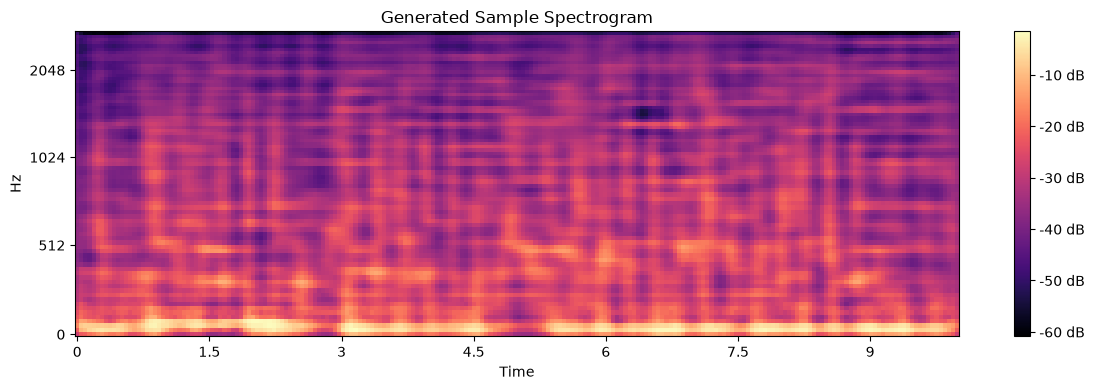

In [8]:

z_sample, mel_sample = sample_latents(
    unet, vae,
    n_samples=1,
    latent_shape=latent_shape,
    latent_mean=latent_mean,
    latent_std=latent_std,
    mel_shape=mel_shape,
)

audio    = mel_tensor_to_audio(mel_sample[0, 0])
out_path = OUTPUT_DIR / GEN_SAMPLE_PATH
sf.write(out_path, audio, SAMPLE_RATE)
print('saved', out_path)

mel_db = mel_sample[0, 0].detach().cpu().numpy() * 80.0 - 80.0
plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_db, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel')
plt.colorbar(format='%2.0f dB')
plt.title('Generated Sample Spectrogram')
plt.tight_layout()
plt.show()

display(Audio(filename=str(out_path), rate=SAMPLE_RATE))